In [1]:
# ============================================
# CONECTAR GOOGLE DRIVE
# ============================================

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================
# IMPORTAR LIBRERIAS
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [4]:
# ============================================
# CARGAR DATASET
# ============================================

ruta = "/content/drive/MyDrive/data sets /House Sales in King County, USA/kc_house_data.csv"

data = pd.read_csv(ruta)

data.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [5]:
# ============================================
# INFORMACION DEL DATASET
# ============================================

print("Numero de ejemplos (m):", data.shape[0])
print("Numero de caracteristicas (n):", data.shape[1])

data.info()

Numero de ejemplos (m): 21613
Numero de caracteristicas (n): 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null 

In [6]:
# ============================================
# PREPROCESAMIENTO
# ============================================

data_numerico = data.select_dtypes(include=[np.number])

data_numerico.head()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [8]:
# ============================================
# DEFINIR VARIABLES
# ============================================

# variable objetivo
y = data_numerico["price"].values

# variables predictoras
X = data_numerico.drop("price", axis=1).values

print("Ejemplos:", X.shape[0])
print("Caracteristicas:", X.shape[1])

Ejemplos: 21613
Caracteristicas: 19


In [9]:
# ============================================
# NORMALIZACION
# ============================================

def normalizar(X):

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma


X_norm, mu, sigma = normalizar(X)

print("Normalizacion completada")

Normalizacion completada


In [10]:
# ============================================
# AGREGAR COLUMNA DE 1
# ============================================

m = X_norm.shape[0]

X = np.concatenate([np.ones((m,1)), X_norm], axis=1)

In [11]:
# ============================================
# INICIALIZAR THETA
# ============================================

n = X.shape[1]

theta = np.zeros(n)

print(theta)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [12]:
# ============================================
# FUNCION DE COSTO
# ============================================

def calcularCosto(X,y,theta):

    m = len(y)

    pred = X.dot(theta)

    error = pred - y

    J = (1/(2*m)) * np.sum(error**2)

    return J

In [13]:
# ============================================
# GRADIENTE DESCENDENTE
# ============================================

def gradienteDescendente(X,y,theta,alpha,iteraciones):

    m = len(y)

    historial = []

    for i in range(iteraciones):

        pred = X.dot(theta)

        error = pred - y

        theta = theta - (alpha/m)*(X.T.dot(error))

        costo = calcularCosto(X,y,theta)

        historial.append(costo)

    return theta, historial

In [14]:
# ============================================
# ENTRENAR MODELO
# ============================================

alpha = 0.01
iteraciones = 500

theta, historial = gradienteDescendente(X,y,theta,alpha,iteraciones)

print("Theta final:")
print(theta)

Theta final:
[536539.50178964  -3541.12548271 -28222.43511147  29215.89228293
  77014.89454051   4652.42822196   5919.8040298   49953.6473872
  41267.20805037  20986.93324844 100164.19942702  71004.22853591
  26968.68700464 -66099.35578892  11793.53129096 -24254.12040109
  83757.62804258 -30140.80895689  32392.15080864  -9247.3397774 ]


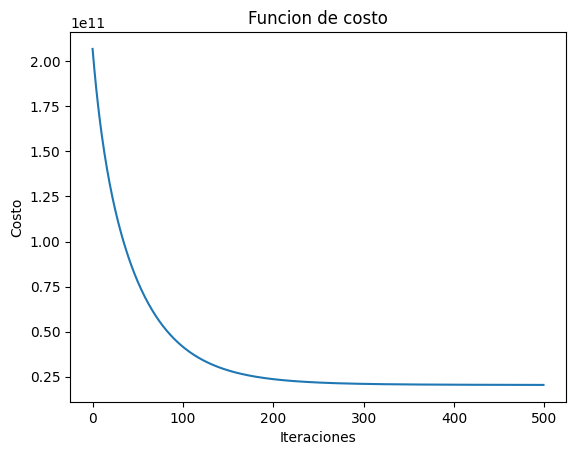

In [15]:
# ============================================
# GRAFICO DE COSTO
# ============================================

plt.plot(historial)

plt.xlabel("Iteraciones")
plt.ylabel("Costo")

plt.title("Funcion de costo")

plt.show()

In [16]:
# ============================================
# REGRESION POLINOMICA
# ============================================

X_poly = np.concatenate([X, X[:,1:]**2], axis=1)

theta_poly = np.zeros(X_poly.shape[1])

theta_poly, historial_poly = gradienteDescendente(
    X_poly, y, theta_poly, 0.01, 500
)

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipykernel_256/1499523949.py:13: RuntimeWarning: overflow encountered in square
  J = (1/(2*m)) * np.sum(error**2)


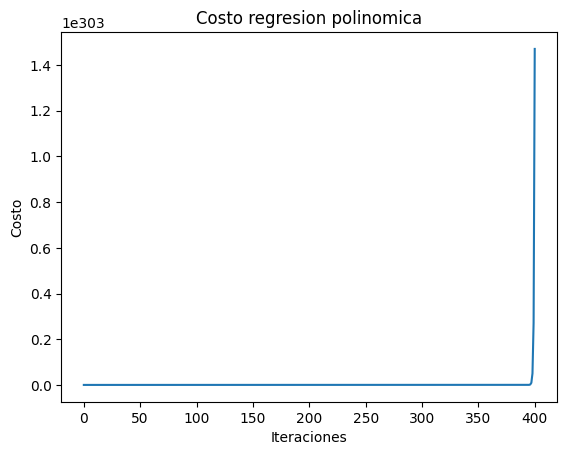

In [17]:
plt.plot(historial_poly)

plt.xlabel("Iteraciones")
plt.ylabel("Costo")

plt.title("Costo regresion polinomica")

plt.show()

In [18]:
# ============================================
# ECUACION NORMAL
# ============================================

theta_normal = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)

print(theta_normal)

[ 540088.14176653   -9786.42171045  -18708.02592747  283777.17515849
  215476.42975142    9991.43810221   47480.74877287   47924.07661383
   39405.546394     27655.37050439  136202.39314728 -353143.09785349
 -133654.93234023  -77022.70965037    7891.11670215  -31152.48150024
   83462.55315432  -29966.53309969   14821.6791578   -10824.29232638]


In [19]:
# ============================================
# PREDICCIONES
# ============================================

predicciones = X.dot(theta)

print(predicciones[:100])

[ 204067.94002386  736777.43147101  395803.78807942  462063.87616945
  433368.25205271 1455022.41450413  285008.39386156  146588.44206075
  334729.79733669  266291.1000481   839920.20844259  426099.5845913
  585718.45549349  312262.85965659  583369.82534847  935510.91361214
  455999.22645433  529098.24201597  290189.54641299  195063.50748195
  466221.88311838 1132102.31843295  342012.2622946   112045.92298296
  538112.9970535   287697.04730703  769331.17761546  638686.96940041
  448436.20837308  661709.80012315  544988.67723924  345956.1238131
  641980.31764667  540785.1733283   324154.29847895  789990.96447317
  210402.55633653  829920.63050567   83334.45138435  593830.63425951
  662192.57614028  744594.38431088  885901.91325964  493076.4258144
  155471.55305969  817380.99497619   24574.65789246  759368.99932502
  401081.75737459 1518560.45783675  176022.86239883  649444.56384749
  465398.86403158  491448.22652817  788123.85947264  757430.04428954
  287625.16039965  473942.89180276 10